In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import glob
import tqdm


In [24]:
etam_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/m6A_eTAM_HeLa.tsv", sep="\t")
print(etam_df)

          chr        pos str  methylation chrstrand            NMID  \
0       chr22   42210158   -       16.512    chr22-     NM_005650.4   
1       chr22   42210158   -       16.512    chr22-     NM_181492.3   
2       chr22   42210158   -       16.512    chr22-  NM_001378418.1   
3       chr22   42210232   -       68.441    chr22-     NM_005650.4   
4       chr22   42210232   -       68.441    chr22-     NM_181492.3   
...       ...        ...  ..          ...       ...             ...   
166448   chr3  149519088   -       35.781     chr3-     NM_015472.6   
166449   chr3  149519209   -       13.728     chr3-  NM_001348362.2   
166450   chr3  149519209   -       13.728     chr3-  NM_001168278.3   
166451   chr3  149519209   -       13.728     chr3-  NM_001168280.3   
166452   chr3  149519209   -       13.728     chr3-     NM_015472.6   

        transcript_coordinate  
0                        5283  
1                        5497  
2                        5497  
3                  

In [6]:
other_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/m6A_Jungmin_110823.tsv", sep="\t")

In [4]:
print(other_df)

          chr str       pos       DoM    SAC  GLORI  MICLIP2  M6ACE  \
0        chrX   +  47054489  0.288278  False   True    False  False   
1        chrX   +  47054489  0.288278  False   True    False  False   
2        chrX   +  47058193  0.130435  False   True    False  False   
3        chrX   +  47058193  0.130435  False   True    False  False   
4        chrX   +  47058259  0.000000   True  False    False  False   
...       ...  ..       ...       ...    ...    ...      ...    ...   
2803625  chr3   -  48165668  0.000000   True  False    False  False   
2803626  chr3   -  48165733  0.021908  False   True    False  False   
2803627  chr3   -  48165733  0.021908  False   True    False  False   
2803628  chr3   -  48167902  0.000000   True  False    False  False   
2803629  chr3   -  48167902  0.000000   True  False    False  False   

         validated chrstrand          NMID  transcript_coordinate  
0                1     chrX+  NM_001077445                   1355  
1          

In [ ]:
other_df = other_df[["SAC", "MICLIP2", "M6ACE", "NMID", "transcript_coordinate"]]
other_df = other_df[other_df[["SAC", "MICLIP2", "M6ACE"]].any(axis=1)]
print(other_df)

In [25]:
etam_df  = etam_df[["methylation", "NMID", "transcript_coordinate"]]
etam_df["ETAM"] = True
etam_df["NMID"] = etam_df["NMID"].str.split(".").str[0]
etam_df.rename(columns={"methylation": "DoM"}, inplace=True)

print(etam_df)


           DoM          NMID  transcript_coordinate  ETAM
0       16.512     NM_005650                   5283  True
1       16.512     NM_181492                   5497  True
2       16.512  NM_001378418                   5497  True
3       68.441     NM_005650                   5209  True
4       68.441     NM_181492                   5423  True
...        ...           ...                    ...   ...
166448  35.781     NM_015472                   3182  True
166449  13.728  NM_001348362                   3252  True
166450  13.728  NM_001168278                   3054  True
166451  13.728  NM_001168280                   3001  True
166452  13.728     NM_015472                   3061  True

[166453 rows x 4 columns]


In [26]:
joint_df = pd.merge(etam_df, other_df, on=["NMID", "transcript_coordinate"], how="outer")
print(joint_df)

            DoM          NMID  transcript_coordinate  ETAM    SAC MICLIP2  \
0        16.512     NM_005650                   5283  True    NaN     NaN   
1        16.512     NM_181492                   5497  True    NaN     NaN   
2        16.512  NM_001378418                   5497  True    NaN     NaN   
3        68.441     NM_005650                   5209  True  False    True   
4        68.441     NM_181492                   5423  True  False    True   
...         ...           ...                    ...   ...    ...     ...   
2199316     NaN     NM_001789                   1644   NaN   True   False   
2199317     NaN     NM_201567                   1507   NaN   True   False   
2199318     NaN     NM_001789                   1627   NaN   True   False   
2199319     NaN     NM_201567                   1321   NaN   True   False   
2199320     NaN     NM_001789                   1441   NaN   True   False   

         M6ACE  
0          NaN  
1          NaN  
2          NaN  
3      

In [27]:
joint_df["DoM"] = joint_df["DoM"].fillna(0)
joint_df["ETAM"] = joint_df["ETAM"].fillna(False)
joint_df["SAC"] = joint_df["SAC"].fillna(False)
joint_df["MICLIP2"] = joint_df["MICLIP2"].fillna(False)
joint_df["M6ACE"] = joint_df["M6ACE"].fillna(False)

print(joint_df)

            DoM          NMID  transcript_coordinate   ETAM    SAC  MICLIP2  \
0        16.512     NM_005650                   5283   True  False    False   
1        16.512     NM_181492                   5497   True  False    False   
2        16.512  NM_001378418                   5497   True  False    False   
3        68.441     NM_005650                   5209   True  False     True   
4        68.441     NM_181492                   5423   True  False     True   
...         ...           ...                    ...    ...    ...      ...   
2199316   0.000     NM_001789                   1644  False   True    False   
2199317   0.000     NM_201567                   1507  False   True    False   
2199318   0.000     NM_001789                   1627  False   True    False   
2199319   0.000     NM_201567                   1321  False   True    False   
2199320   0.000     NM_001789                   1441  False   True    False   

         M6ACE  
0        False  
1        False  


In [28]:
joint_df["validated"] = joint_df[["SAC", "MICLIP2", "M6ACE", "ETAM"]].sum(axis=1)
print(joint_df["validated"].value_counts())
joint_df["DoM"] = joint_df["DoM"] / 100

joint_df.to_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/m6A_HeLa.tsv", sep="\t", index=False)

validated
1    1912532
2     219323
3      54840
4      12626
Name: count, dtype: int64


In [2]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/Baeklab.070.eTAM.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df_filtered = label_df[(label_df["dom_label"] > 0.0) | (label_df["label"] == 0)].copy()
label_df_filtered["label"] = label_df_filtered["dom_label"] > 0.0
print(label_df_filtered["label"].value_counts())



label
False    12230399
True       103542
Name: count, dtype: int64


In [3]:
cell_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(cell_df, allow_pickle=True) as data:
    cell_df = pd.DataFrame({key: data[key] for key in data.keys()})
cell_df = cell_df[cell_df["count_dom"] >= 20]
print(cell_df)

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000   0.606511      0.000000        0.000000          0   
1         NM_000016:1008   0.948786      0.000000        0.000000          0   
2         NM_000016:1009   2.607620      0.000000        0.000000          0   
3         NM_000016:1010   4.912612      0.000000        0.000000          0   
4         NM_000016:1014   3.237954      0.000000        0.000000          0   
...                  ...        ...           ...             ...        ...   
30894417    NR_184306:85   1.133184      0.000000        0.000000          0   
30894420    NR_184306:87   3.771550     -0.001452       -2.476578          1   
30894423    NR_184306:88   2.137289      0.000000        0.000000          0   
30894435    NR_184306:93  32.341377     -0.011076      -78.301079         23   
30894446    NR_184306:98   4.046034      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg 

In [4]:
cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")
print(cell_label_df)

               label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0        NM_000016:1000   0.606511      0.000000        0.000000          0   
1        NM_000016:1008   0.948786      0.000000        0.000000          0   
2        NM_000016:1009   2.607620      0.000000        0.000000          0   
3        NM_000016:1010   4.912612      0.000000        0.000000          0   
4        NM_000016:1014   3.237954      0.000000        0.000000          0   
...                 ...        ...           ...             ...        ...   
7831386  NR_182669:3969   1.723521      0.000000        0.000000          0   
7831387  NR_182751:2277   8.478946     -0.009655      -19.475899          7   
7831388   NR_182751:506   1.901786      0.000000        0.000000          0   
7831389  NR_182754:2730   1.667113      0.000000        0.000000          0   
7831390   NR_183625:499  23.870399     -0.014579      -64.044052         21   

         logsum_p_neg  logsum_1_p_neg  count_neg  l

In [5]:
cell_label_df["pm6a"] =  -(2-cell_label_df["dom"])*cell_label_df["logsum_1_p_pos"]/cell_label_df["count_all"] + ((1-cell_label_df["dom"])*np.log10(np.clip(1-cell_label_df["dom"],1e-30,1)) + cell_label_df["dom"] * np.log10(np.clip(cell_label_df["dom"],1e-30,1)))*(cell_label_df["count_pos"]/cell_label_df["count_all"])

               label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
66       NM_000016:1218   3.342309     -0.013035       -6.126953          3   
73       NM_000016:1232   1.903287     -0.002427       -2.254001          1   
78       NM_000016:1244   4.040272     -0.000032       -4.128505          1   
79       NM_000016:1245   4.232924     -0.001182       -5.788179          2   
97       NM_000016:1302  59.435646     -0.070924     -143.232574         53   
...                 ...        ...           ...             ...        ...   
7831314  NR_182669:3702   1.442454     -0.002071       -2.322619          1   
7831344  NR_182669:3813   1.035196     -0.000701       -2.792167          1   
7831374  NR_182669:3949   4.004800     -0.013700       -9.599714          4   
7831387  NR_182751:2277   8.478946     -0.009655      -19.475899          7   
7831390   NR_183625:499  23.870399     -0.014579      -64.044052         21   

         logsum_p_neg  logsum_1_p_neg  count_neg  l

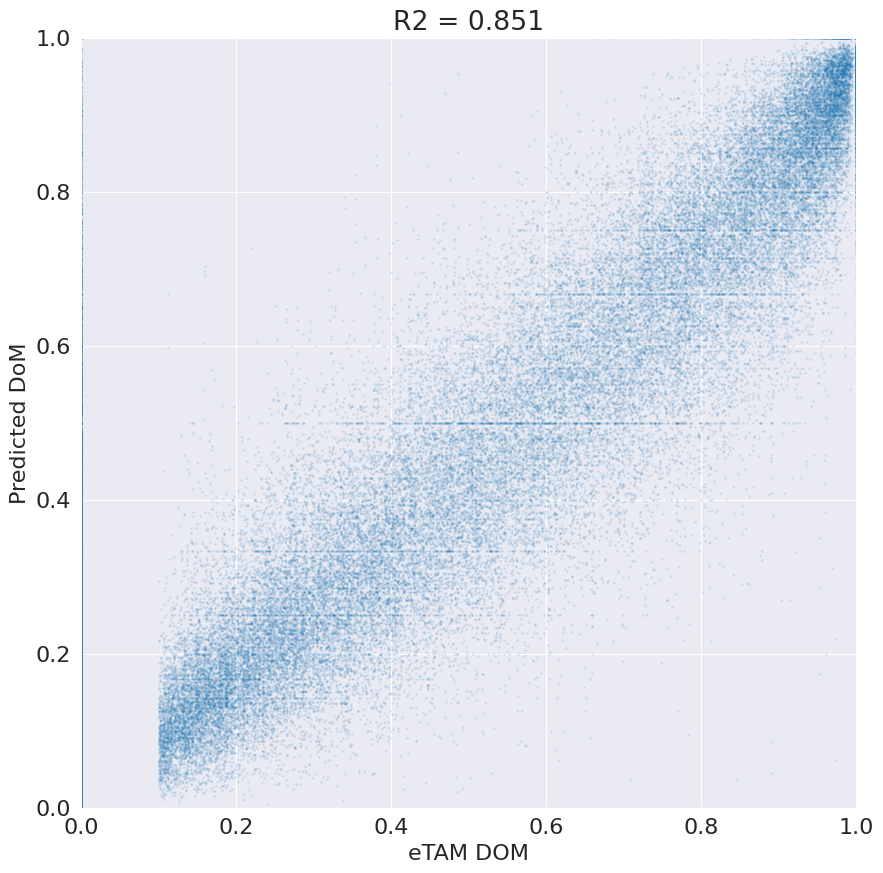

In [13]:
## Plot scatter
cell_label_df["pm6aold"] = 1-10**(cell_label_df["logsum_1_p_pos"]/cell_label_df["count_all"])
cell_label_df["threshold"] = 1-(0.02 ** (cell_label_df["dom"]))
selected_df = cell_label_df[cell_label_df["pm6aold"] > cell_label_df["threshold"]]
print(selected_df)

plt.rcParams.update({'font.size': 16})

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("eTAM DOM")
ax.set_ylabel("Predicted DoM")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"R2 = {r2:.3f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()


In [41]:
cell_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_dwell_bq_npz-ON0091_allmotif_pileup/pileup.pkl")
cell_df = cell_df[cell_df["count_pm6a"] >= 20]
print(cell_df)

cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")
print(cell_label_df)


                label_id      pm6a  count_pm6a       dom  count_dom  mean_pred
0         NM_000016:1000  0.001015       307.0  0.000000        309   0.001917
1         NM_000016:1008  0.000845       306.0  0.003247        308   0.003463
2         NM_000016:1009  0.001911       306.0  0.003236        309   0.005253
3         NM_000016:1010  0.002840       303.0  0.012862        311   0.013111
4         NM_000016:1014  0.004780       299.0  0.013158        304   0.016140
...                  ...       ...         ...       ...        ...        ...
26454124    NR_184306:77  0.827938        26.0  0.230769         26   0.234885
26454137    NR_184306:85  0.018644        21.0  0.041667         24   0.055555
26454140    NR_184306:87  0.018570        22.0  0.107143         28   0.112035
26454143    NR_184306:88  0.016222        26.0  0.034483         29   0.048587
26454155    NR_184306:93  0.987643        22.0  0.666667         24   0.660487

[13019098 rows x 6 columns]
               label_id

               label_id      pm6a  count_pm6a       dom  count_dom  mean_pred  \
97       NM_000016:1302  0.828286       295.0  0.263158        304   0.264927   
307      NM_000016:1882  0.387690       296.0  0.086093        302   0.089166   
841      NM_000021:1584  0.998911        88.0  0.921348         89   0.918813   
860      NM_000021:1641  0.583695        82.0  0.137931         87   0.136244   
862      NM_000021:1655  0.956187        76.0  0.488636         88   0.480976   
...                 ...       ...         ...       ...        ...        ...   
6951019  NR_184208:2817  0.222229       124.0  0.038168        131   0.046613   
6951034  NR_184208:2919  0.670510        99.0  0.206897        116   0.211380   
6951066  NR_184208:3139  0.511927       121.0  0.120301        133   0.124006   
6951074  NR_184208:3186  0.646963        96.0  0.178571        112   0.192851   
6951176   NR_184208:802  0.222232        30.0  0.033333         30   0.038873   

         depth  label  dom_

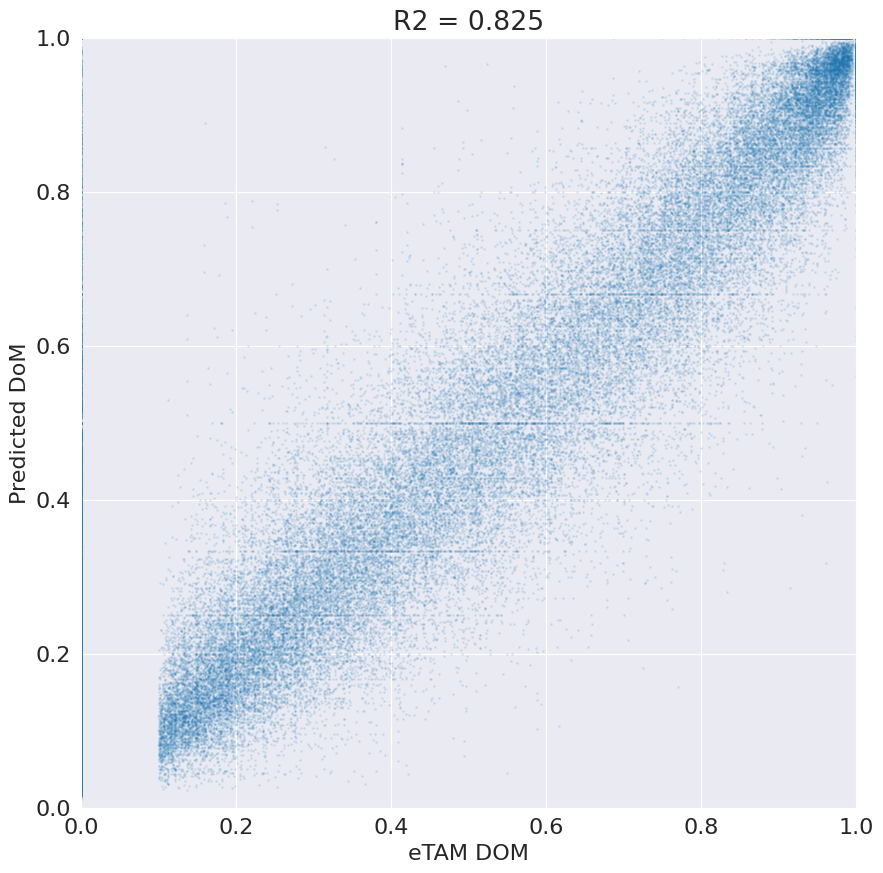

In [49]:
## Plot scatter
cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (cell_label_df["dom"])))
selected_df = cell_label_df[(cell_label_df["pm6a"] > cell_label_df["threshold"])]
print(selected_df)

plt.rcParams.update({'font.size': 16})

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("eTAM DOM")
ax.set_ylabel("Predicted DoM")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"R2 = {r2:.3f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()


In [50]:


def process_dorado_inferece(data_path):
    if data_path is None:
        return None
    if os.path.exists(data_path.replace(".bed", ".drach.pkl")):
        data_df = pd.read_pickle(data_path.replace(".bed", ".drach.pkl"))
    elif os.path.exists(data_path.replace(".bed", ".pkl")):
        data_df = pd.read_pickle(data_path.replace(".bed", ".pkl"))
    else:
        data_df = pd.read_csv(data_path, quoting = 3, sep = "\t", header = None, dtype=str)
        ## Keep column 0, 1, 4, 9
        data_df = data_df[[0, 1, 4, 9]]
        data_df.columns = ["nmid", "pos", "depth", "pred_dorado"]
        data_df["depth"] = data_df["depth"].astype(int)
        data_df["pred_dorado"] = data_df["pred_dorado"].str.split(" ").str[1].astype(float) / 100
        data_df["label_id"] = data_df["nmid"].str.split(".").str[0] + ":" + data_df["pos"]
        data_df = data_df[["label_id", "pred_dorado","depth"]].copy()
        data_df.rename(columns = {"depth": "dorado_count"}, inplace = True)
        data_df.to_pickle(data_path.replace(".bed", ".pkl"))

    return data_df

In [51]:
dorado_df = process_dorado_inferece("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/dorado-070-aligned/intermediates/dorado_output.modkit.bed")

In [ ]:
print(dorado_df)
dorado_label_df = dorado_df.merge(label_df_filtered, on="label_id", how="inner")
print(dorado_label_df)

In [57]:
dorado_label_df = dorado_label_df[dorado_label_df["dorado_count"] >= 20]

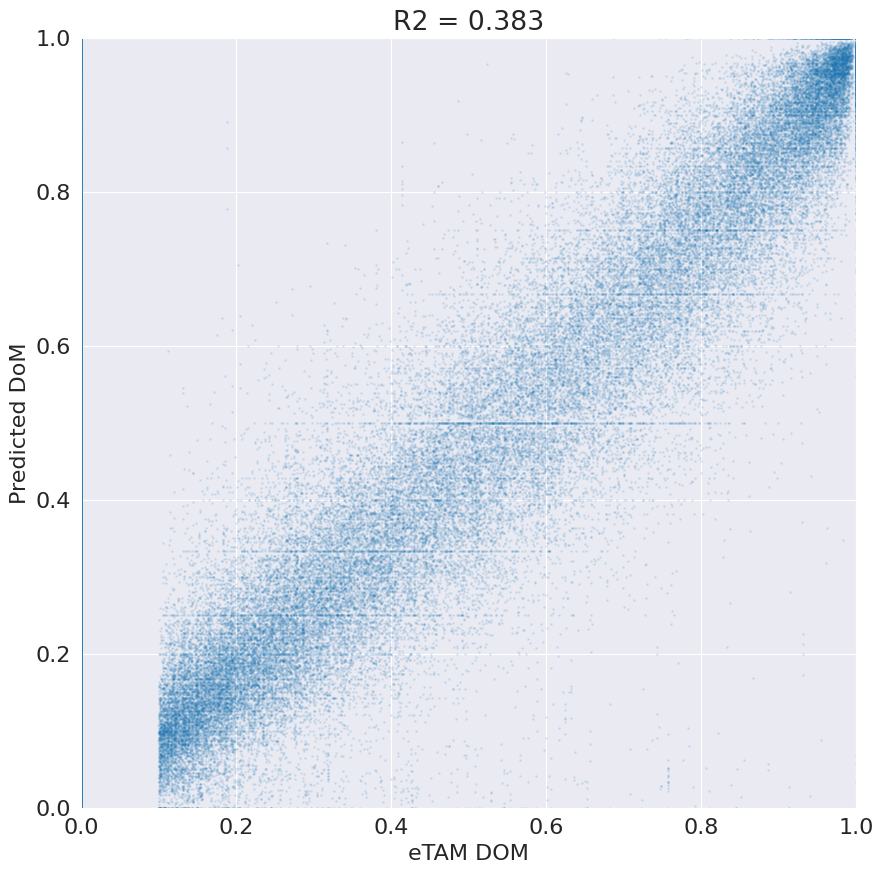

In [58]:
selected_df = dorado_label_df

plt.rcParams.update({'font.size': 16})

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["pred_dorado"], alpha=0.1, s = 1)
ax.set_xlabel("eTAM DOM")
ax.set_ylabel("Predicted DoM")
r2 = pearsonr(selected_df["dom_label"], selected_df["pred_dorado"])[0] ** 2
ax.set_title(f"R2 = {r2:.3f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()


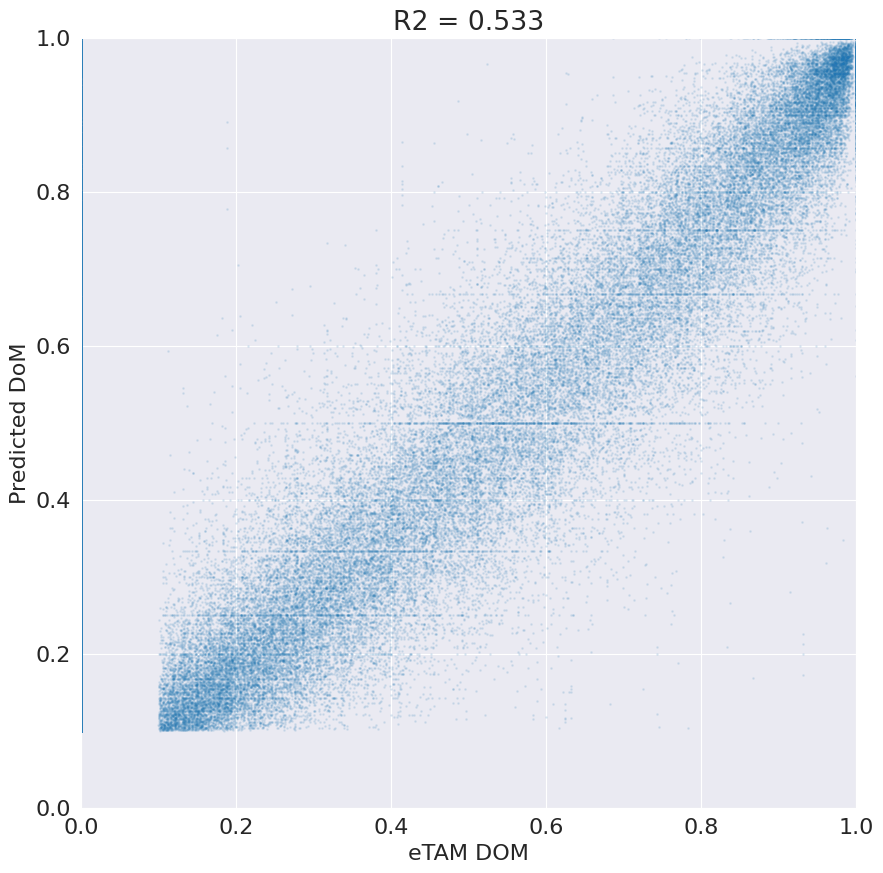

In [59]:
selected_df = dorado_label_df[dorado_label_df["pred_dorado"] > 0.1]

plt.rcParams.update({'font.size': 16})

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["pred_dorado"], alpha=0.1, s = 1)
ax.set_xlabel("eTAM DOM")
ax.set_ylabel("Predicted DoM")
r2 = pearsonr(selected_df["dom_label"], selected_df["pred_dorado"])[0] ** 2
ax.set_title(f"R2 = {r2:.3f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()
